**Create E-commerce transaction data of 20 rows and 10 columns.**

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic data
data = {
    'transaction_id': [f'TRX_{1000+i}' for i in range(20)],
    'date': [(datetime(2023, 1, 1) + timedelta(days=np.random.randint(0, 365))).strftime('%Y-%m-%d') for _ in range(20)],
    'customer_id': [f'CUST_{np.random.randint(100, 150)}' for _ in range(20)],
    'product_name': np.random.choice(['Laptop', 'Smartphone', 'Headphones', 'Tablet', 'Smartwatch'], 20),
    'category': np.random.choice(['Electronics', 'Accessories'], 20),
    'quantity': np.random.randint(1, 5, size=20),
    'unit_price': np.round(np.random.uniform(50, 1200, size=20), 2),
    'payment_method': np.random.choice(['Credit Card', 'PayPal', 'Debit Card'], 20),
    'shipping_status': np.random.choice(['Shipped', 'Delivered', 'Processing'], 20),
    'is_returned': np.random.choice([True, False], 20, p=[0.1, 0.9])
}

df = pd.DataFrame(data)

# Calculate a derived column to ensure we have exactly 10 columns as requested
# (The 10 columns are defined in the 'data' dictionary above)

print(f"DataFrame Shape: {df.shape}")
display(df.head(20))

DataFrame Shape: (20, 10)


,transaction_id,date,customer_id,product_name,category,quantity,unit_price,payment_method,shipping_status,is_returned
0,TRX_1000,2023-04-13,CUST_143,Headphones,Accessories,2,373.07,Debit Card,Processing,False
1,TRX_1001,2023-12-15,CUST_129,Smartwatch,Accessories,3,674.10,PayPal,Shipped,True
2,TRX_1002,2023-09-28,CUST_137,Laptop,Accessories,4,212.06,Credit Card,Processing,False
3,TRX_1003,2023-04-17,CUST_101,Smartphone,Accessories,3,972.53,Debit Card,Processing,False
4,TRX_1004,2023-03-13,CUST_120,Tablet,Accessories,4,135.73,PayPal,Delivered,False
5,TRX_1005,2023-07-08,CUST_132,Laptop,Accessories,2,1184.92,Debit Card,Delivered,False
6,TRX_1006,2023-01-21,CUST_111,Tablet,Accessories,3,938.08,Debit Card,Shipped,False
7,TRX_1007,2023-04-13,CUST_121,Smartphone,Accessories,4,278.52,Credit Card,Processing,False
8,TRX_1008,2023-05-02,CUST_143,Smartphone,Accessories,1,56.35,Debit Card,Processing,False
9,TRX_1009,2023-08-03,CUST_124,Laptop,Accessories,2,987.78,Credit Card,Processing,False


**Data Inspection & Summary**

In [ ]:
# Display the first 5 rows
print("First 5 rows of the dataset:")
display(df.head(5))

# Check data types and non-null counts
print("\nDataset Information:")
df.info()

# Statistical summary of numerical columns
print("\nStatistical Summary:")
display(df.describe())

First 5 rows of the dataset:


,transaction_id,date,customer_id,product_name,category,quantity,unit_price,payment_method,shipping_status,is_returned
0,TRX_1000,2023-04-13,CUST_143,Headphones,Accessories,2,373.07,Debit Card,Processing,False
1,TRX_1001,2023-12-15,CUST_129,Smartwatch,Accessories,3,674.10,PayPal,Shipped,True
2,TRX_1002,2023-09-28,CUST_137,Laptop,Accessories,4,212.06,Credit Card,Processing,False
3,TRX_1003,2023-04-17,CUST_101,Smartphone,Accessories,3,972.53,Debit Card,Processing,False
4,TRX_1004,2023-03-13,CUST_120,Tablet,Accessories,4,135.73,PayPal,Delivered,False



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transaction_id   20 non-null     object 
 1   date             20 non-null     object 
 2   customer_id      20 non-null     object 
 3   product_name     20 non-null     object 
 4   category         20 non-null     object 
 5   quantity         20 non-null     int64  
 6   unit_price       20 non-null     float64
 7   payment_method   20 non-null     object 
 8   shipping_status  20 non-null     object 
 9   is_returned      20 non-null     bool   
dtypes: bool(1), float64(1), int64(1), object(7)
memory usage: 1.6+ KB

Statistical Summary:


,quantity,unit_price
count,20.000000,20.000000
mean,2.550000,582.248500
std,1.190975,378.057003
min,1.000000,56.350000
25%,1.750000,204.857500
50%,2.500000,568.170000
75%,4.000000,937.240000
max,4.000000,1184.920000


**Data Cleaning**

In [ ]:
# 1. Check for missing (null) values
print("Missing values per column:")
print(df.isnull().sum())

# Handle missing values: Fill numerical columns with the median
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# 2. Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

# Handle duplicates: Drop them if they exist
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

# 3. Convert 'date' column to datetime object
df['date'] = pd.to_datetime(df['date'])

# Verification
print("\nFinal Data Types:")
print(df.dtypes)
display(df.head())

Missing values per column:
transaction_id     0
date               0
customer_id        0
product_name       0
category           0
quantity           0
unit_price         0
payment_method     0
shipping_status    0
is_returned        0
dtype: int64

Number of duplicate rows: 0

Final Data Types:
transaction_id             object
date               datetime64[ns]
customer_id                object
product_name               object
category                   object
quantity                    int64
unit_price                float64
payment_method             object
shipping_status            object
is_returned                  bool
dtype: object


,transaction_id,date,customer_id,product_name,category,quantity,unit_price,payment_method,shipping_status,is_returned
0,TRX_1000,2023-04-13,CUST_143,Headphones,Accessories,2,373.07,Debit Card,Processing,False
1,TRX_1001,2023-12-15,CUST_129,Smartwatch,Accessories,3,674.10,PayPal,Shipped,True
2,TRX_1002,2023-09-28,CUST_137,Laptop,Accessories,4,212.06,Credit Card,Processing,False
3,TRX_1003,2023-04-17,CUST_101,Smartphone,Accessories,3,972.53,Debit Card,Processing,False
4,TRX_1004,2023-03-13,CUST_120,Tablet,Accessories,4,135.73,PayPal,Delivered,False


**Univariate Analysis**

/tmp/ipykernel_792/2553622749.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', ax=axes[0], palette='viridis')


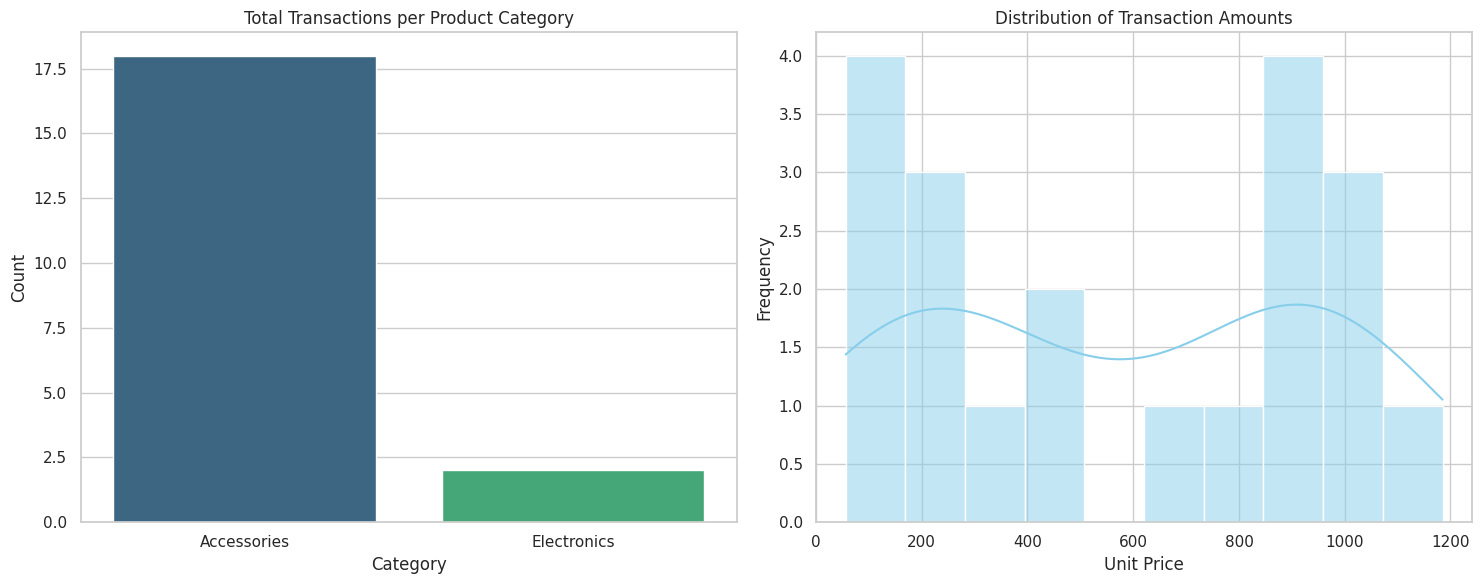

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Bar chart: count of transactions per product category
sns.countplot(data=df, x='category', ax=axes[0], palette='viridis')
axes[0].set_title('Total Transactions per Product Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')

# 2. Histogram: distribution of transaction amounts (unit_price)
sns.histplot(df['unit_price'], bins=10, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Transaction Amounts')
axes[1].set_xlabel('Unit Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Bivariate & Multivariate Analysis**

Top 3 Customers by Total Spending:
customer_id
CUST_143    3869.65
CUST_141    3747.84
CUST_148    3451.56
Name: total_spent, dtype: float64


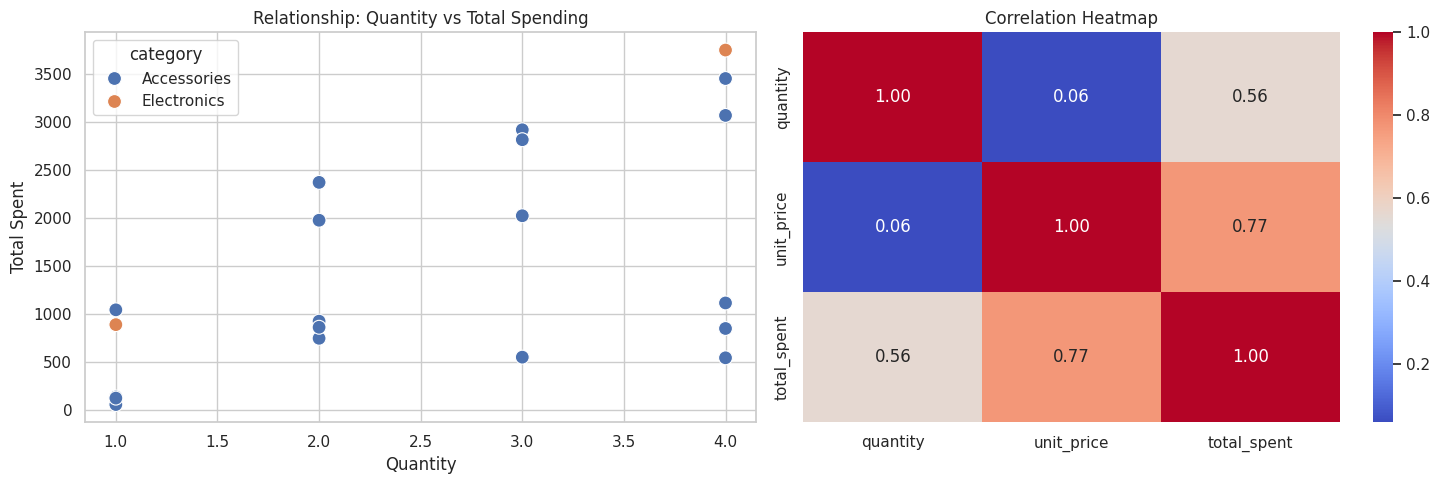

In [ ]:
# 1. Top 3 customers based on total spending
# Note: Total spending is quantity * unit_price
df['total_spent'] = df['quantity'] * df['unit_price']
top_3_customers = df.groupby('customer_id')['total_spent'].sum().nlargest(3)
print("Top 3 Customers by Total Spending:")
print(top_3_customers)

# Set up the visualization environment
plt.figure(figsize=(15, 5))

# 2. Scatter plot: Quantity vs Total Spent
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='quantity', y='total_spent', hue='category', s=100)
plt.title('Relationship: Quantity vs Total Spending')
plt.xlabel('Quantity')
plt.ylabel('Total Spent')

# 3. Correlation heatmap for numerical variables
plt.subplot(1, 2, 2)
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

**Time Series Trends**

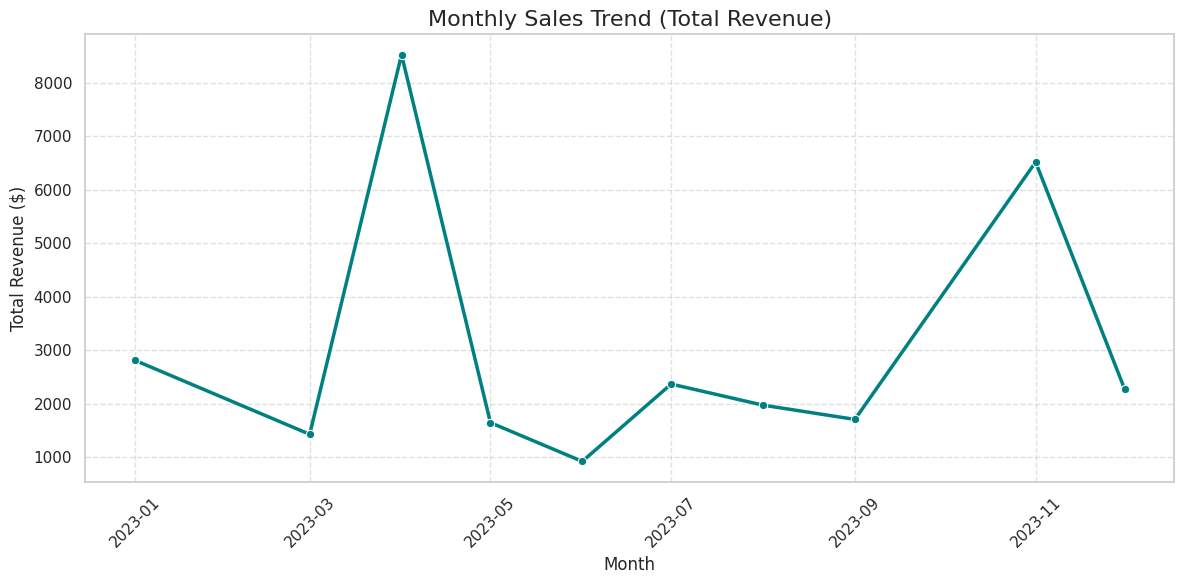

In [ ]:
# Extract month from the date
df['month'] = df['date'].dt.to_period('M')

# Calculate total revenue per month
monthly_sales = df.groupby('month')['total_spent'].sum().reset_index()

# Convert 'month' back to timestamp for plotting compatibility
monthly_sales['month'] = monthly_sales['month'].dt.to_timestamp()

# Plot the sales trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='month', y='total_spent', marker='o', color='teal', linewidth=2.5)

plt.title('Monthly Sales Trend (Total Revenue)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()